In [1]:
from regions import Regions, CirclePixelRegion, CircleSkyRegion, PixCoord
from astropy import wcs
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib import pyplot as plt
from multiprocessing.pool import ThreadPool as Pool
import hdbscan
import numpy as np
import miniball
import time as t
import os
import glob
from astropy.coordinates import SkyCoord
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment

%matplotlib widget


Ficheros de control para verificar el algoritmo:
* Object: M31, Obs: 0405320501 (Andromeda Galaxy)
* Object: SN 1987A, Obs: 0804980201 (Supernova)
* Object: XTE J1719-291, Obs: 0552002601 (Transient)\
Descargados del archivo de XMM-Newton con el script utils/download_dataset_files.bat/sh script

In [2]:
# Sólo es necesario indicar la observación
OBS = "0405320501"

# Ficheros de control
#OBS = "0405320501" # M31           - Galaxy
#OBS = "0804980201" # SN 1987A      - Supernova
#OBS = "0552002601" # XTE J1719-291 - Transient

INST = "PN"
base_dir = f'../dataset/{OBS}/pps'

def find_event_file_and_exposure(obs, inst='PN', base_dir=None):
    if base_dir is None:
        base_dir = f'../dataset/{obs}/pps'

    pattern = os.path.join(base_dir, f'P{obs}{inst}S???PIEVLI0000.FTZ')
    candidates = sorted(glob.glob(pattern))
    if not candidates:
        raise FileNotFoundError(f'No se encontró ningún fichero PIEVLI para {obs} en {base_dir}')

    event_file = candidates[0]
    fname = os.path.basename(event_file)
    exposure = fname[len(f'P{obs}{inst}'):len(f'P{obs}{inst}') + 4]
    return event_file, exposure

event_file, EXPOSURE = find_event_file_and_exposure(OBS, INST, base_dir)
region_list = os.path.join(base_dir, f'P{OBS}EPX000REGION0000.ASC')
hdbscan_region_list = os.path.join(base_dir, f'P{OBS}EPX000HDBSCANREG.ASC')
hdbscan_region_list_all = os.path.join(base_dir, f'P{OBS}EPX001HDBSCANREG.ASC')

print(f'Observación: {OBS}')
print(f'Evento seleccionado: {os.path.basename(event_file)}')
print(f'Instrumento: {INST}')
print(f'Exposición detectada: {EXPOSURE}')


Observación: 0405320501
Evento seleccionado: P0405320501PNS001PIEVLI0000.FTZ
Instrumento: PN
Exposición detectada: S001


Reading Coord info from event file header

In [3]:
with fits.open(event_file, mode='readonly', ignore_missing_end=True) as hdul:
    header = hdul[0].header
    evList = hdul['EVENTS'].data

DURATION = header['DURATION']
OBJECT   = header['OBJECT']
REFXCRPX = header['REFXCRPX']
REFYCRPX = header['REFYCRPX']
REFXCDLT = header['REFXCDLT']
REFYCDLT = header['REFYCDLT']
REFXCRVL = header['REFXCRVL']
REFYCRVL = header['REFYCRVL']
REFXCTYP = header['REFXCTYP']
REFYCTYP = header['REFYCTYP']
RADECSYS = header['RADECSYS']
EQUINOX = header['EQUINOX']

w = wcs.WCS(naxis = 2)
w.wcs.crpix = [REFXCRPX, REFYCRPX]
w.wcs.cdelt = np.array([REFXCDLT, REFYCDLT])
w.wcs.crval = [REFXCRVL, REFYCRVL]
w.wcs.ctype = [REFXCTYP, REFYCTYP]
w.wcs.radesys = RADECSYS
w.wcs.equinox = EQUINOX

Setting the coord info with WCS

In [4]:
#w.wcs.print_contents()
w

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : '' ''
CRVAL : 10.654625 41.2869166666667
CRPIX : 25921.0 25921.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -1.38888888888889e-05 1.38888888888889e-05
NAXIS : 0  0

In [5]:
# Defining min, máx values from specifications:
CCD_RAWX_MIN = 1
CCD_RAWX_MAX = 64

CCD_RAWY_MIN = 2
CCD_RAWY_MAX = 199

PIMIN = 300
PIMAX = 7000

MAX_RADIUS = int(REFXCRPX/32)
MAX_CLUSTER = 100000
MAX_NCLUSTERS = 20 # per CCD

NUMTHREADS = 8

In [6]:
# Global configuration to align with hdbscan_ccd_v2_6.py
VERSION = "v2.6"

DETECTIONMODE = "spatiotemporal"  # 'spatial' or 'spatiotemporal'
TIMESCALESECONDS = 5000.0
TIMEWEIGHT = 0.2
HYPERPARAMETERPROFILE = "Brecallplus"

CLUSTERSELECTIONMETHOD = "eom"
METRIC = "euclidean"
MINCLUSTERSIZE = 30
MINSAMPLES = 15
MINPERSISTENCE = 0.03
MINMEANPROBABILITY = 0.08
MINCLUSTEREVENTS = 40
MINRADIUSARCSEC = 6.0
MAXRADIUSARCSEC = 60.0
MATCHTOLERANCEARCSEC = 15.0


Filtering of events with:
FLAG = 0        (good events)
300 < PI < 7000 (energy between these values are reliables)
PATTERN <= 4

## Filtro de radiación de fondo (GTI temporal) — EPIC-pn

Antes de construir `goodEvents` se aplica el cribado oficial SAS de **fulguraciones de
protones blandos (soft-proton flares)** para EPIC-pn. El motivo de calcular el GTI
**antes** del filtro científico es que la curva de luz de fondo debe medirse sobre la
lista de eventos **completa** (`evList`), en la banda dura donde domina el fondo de
partículas, y no sobre los eventos ya filtrados en energía.

**Procedimiento** (`filter_background_gti`):
1. Curva de luz de fondo con `FLAG==0`, `PATTERN==0`, `PI ∈ [10000, 12000] eV`, en bins de
   `bin_seconds` s (100 s por defecto); `rate = cuentas / bin_seconds` (ct/s).
2. Umbral:
   - `method='fixed'`: umbral = `fixed_rate` (0.4 ct/s por defecto).
   - `method='robust'`: **sigma-clipping unilateral iterativo** por mediana y MAD. En cada
     iteración se calcula la mediana y `σ = 1.4826·MAD` de los bins supervivientes y se
     descartan **solo** los bins altos (`rate > mediana + sigma_factor·σ`), que son las
     fulguraciones. El nivel quiescente es la mediana final y el umbral =
     `quiescente + sigma_factor·σ`.
3. `good_bins = rate <= threshold`. Salvaguarda: si se aceptan menos de `min_gti_bins`
   bins, se recurre al umbral fijo `fixed_rate`.
4. Se construye `gti_mask` por evento asignando cada `TIME` a su bin temporal.
5. `goodEvents = evList[ FLAG==0 & PATTERN<=4 & PI∈[300,7000] & gti_mask ]`.

Devuelve un diccionario de diagnóstico con `threshold`, `quiescent_rate`, `robust_sigma`,
`rates`, `bin_centers`, `good_bins`, `gti_mask`, `scientific_before`, `scientific_after`
y `retained_fraction`.

In [7]:
def filter_background_gti(evList, bin_seconds=100, method='robust',
                          fixed_rate=0.4, sigma_factor=3.0, min_gti_bins=5,
                          bkg_pi_min=10000, bkg_pi_max=12000, bkg_pattern=0,
                          sci_pi_min=PIMIN, sci_pi_max=PIMAX,
                          sci_pattern_max=4, max_iter=10):
    """Filtro temporal de radiación de fondo (GTI) para EPIC-pn.

    Calcula el GTI a partir de la lista de eventos ORIGINAL (evList) y devuelve
    goodEvents (filtro científico + máscara GTI) junto con un diccionario de
    diagnóstico. El nivel quiescente robusto se estima con sigma-clipping
    UNILATERAL iterativo por mediana y MAD (solo se recortan los bins altos, que
    corresponden a las fulguraciones de protones blandos).
    """
    time_all = np.asarray(evList.TIME, dtype=float)
    t0 = float(time_all.min())
    t1 = float(time_all.max())

    # 1) Curva de luz de fondo (banda dura, eventos simples, buenos)
    bkg_sel = ((evList.FLAG == 0) & (evList.PATTERN == bkg_pattern) &
               (evList.PI >= bkg_pi_min) & (evList.PI <= bkg_pi_max))
    t_bkg = time_all[np.asarray(bkg_sel, dtype=bool)]

    edges = np.arange(t0, t1 + bin_seconds, bin_seconds)
    counts, _ = np.histogram(t_bkg, bins=edges)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    rates = counts / float(bin_seconds)
    n_bins = len(rates)

    # 2) Umbral
    fallback_note = ""
    if method == 'fixed':
        quiescent_rate = float(np.median(rates)) if n_bins else 0.0
        robust_sigma = float(1.4826 * np.median(np.abs(rates - quiescent_rate))) if n_bins else 0.0
        threshold = float(fixed_rate)
    elif method == 'robust':
        keep = np.ones(n_bins, dtype=bool)
        for _ in range(max_iter):
            med = float(np.median(rates[keep]))
            mad = float(np.median(np.abs(rates[keep] - med)))
            sig = 1.4826 * mad
            if sig <= 0:
                s = float(np.std(rates[keep]))
                sig = s if s > 0 else max(med * 0.1, 1e-6)
            new_keep = rates <= (med + sigma_factor * sig)   # UNILATERAL: solo lado alto
            if new_keep.sum() < 3:
                break
            if np.array_equal(new_keep, keep):
                keep = new_keep
                break
            keep = new_keep
        quiescent_rate = float(np.median(rates[keep]))
        mad_f = float(np.median(np.abs(rates[keep] - quiescent_rate)))
        robust_sigma = 1.4826 * mad_f
        if robust_sigma <= 0:
            s = float(np.std(rates[keep]))
            robust_sigma = s if s > 0 else max(quiescent_rate * 0.1, 1e-6)
        threshold = quiescent_rate + sigma_factor * robust_sigma
    else:
        raise ValueError("method debe ser 'robust' o 'fixed'")

    # 3) Bins aceptados + salvaguarda anti-umbral patologico
    good_bins = rates <= threshold
    if int(good_bins.sum()) < min_gti_bins:
        fallback_note = ("umbral acepta {0} bins (<{1}) -> salvaguarda umbral fijo {2} ct/s"
                         .format(int(good_bins.sum()), min_gti_bins, fixed_rate))
        threshold = float(fixed_rate)
        good_bins = rates <= threshold

    # 4) Mascara GTI por evento (segun su bin temporal)
    bin_idx = np.floor((time_all - t0) / bin_seconds).astype(int)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    gti_mask = good_bins[bin_idx]

    # 5) Filtro científico + GTI -> goodEvents
    sci_mask = ((evList.FLAG == 0) &
                (evList.PI >= sci_pi_min) & (evList.PI <= sci_pi_max) &
                (evList.PATTERN <= sci_pattern_max))
    sci_mask = np.asarray(sci_mask, dtype=bool)
    scientific_before = int(sci_mask.sum())
    final_mask = sci_mask & gti_mask
    goodEvents = evList[final_mask]
    scientific_after = int(final_mask.sum())

    total_span = t1 - t0
    gti_exposure = float(int(good_bins.sum()) * bin_seconds)
    retained_fraction = (scientific_after / scientific_before) if scientific_before else 0.0

    diag = {
        "method": method,
        "bin_seconds": bin_seconds,
        "sigma_factor": sigma_factor,
        "min_gti_bins": min_gti_bins,
        "bkg_band": (bkg_pi_min, bkg_pi_max, bkg_pattern),
        "n_bins": int(n_bins),
        "n_bkg_events": int(t_bkg.size),
        "t0": t0, "t1": t1, "total_span": float(total_span),
        "threshold": float(threshold),
        "quiescent_rate": float(quiescent_rate),
        "robust_sigma": float(robust_sigma),
        "rates": rates,
        "bin_centers": bin_centers,
        "good_bins": good_bins,
        "n_good_bins": int(good_bins.sum()),
        "n_rejected_bins": int((~good_bins).sum()),
        "gti_exposure": gti_exposure,
        "gti_mask": gti_mask,
        "events_total": int(len(evList)),
        "events_after_gti": int(gti_mask.sum()),
        "scientific_before": scientific_before,
        "scientific_after": scientific_after,
        "retained_fraction": float(retained_fraction),
        "fallback_note": fallback_note,
    }
    return goodEvents, diag

In [8]:
# ---- Configuración del filtro de fondo (GTI) ----
APPLYBACKGROUNDGTI = True
BKGBINSECONDS = 100        # ancho de bin de la curva de luz (s)
BKGMETHOD = 'robust'        # 'robust' (mediana iterativa + MAD, unilateral) o 'fixed'
BKGFIXEDRATE = 0.4         # ct/s (método 'fixed' y salvaguarda)
BKGSIGMA = 3.0              # sigma_factor del umbral robusto
MINGTIBINS = 5             # mínimo de bins GTI; si no, salvaguarda a umbral fijo

if APPLYBACKGROUNDGTI:
    goodEvents, gti_diag = filter_background_gti(
        evList, bin_seconds=BKGBINSECONDS, method=BKGMETHOD,
        fixed_rate=BKGFIXEDRATE, sigma_factor=BKGSIGMA, min_gti_bins=MINGTIBINS)
else:
    _sci = ((evList.FLAG == 0) & (evList.PI >= PIMIN) & (evList.PI <= PIMAX) &
            (evList.PATTERN <= 4))
    goodEvents = evList[_sci]
    gti_diag = None

if gti_diag is not None:
    d = gti_diag
    print("==== Filtro de radiación de fondo (GTI) — {0} / {1} ====".format(OBJECT, INST))
    print("Método                      : {0} {1}".format(
        d["method"], ("[" + d["fallback_note"] + "]") if d["fallback_note"] else ""))
    print("Bin                         : {0} s  ({1} bins)".format(d["bin_seconds"], d["n_bins"]))
    print("Banda de fondo              : PI [{0},{1}] eV, PATTERN=={2}, FLAG==0".format(*d["bkg_band"]))
    print("Eventos de fondo (banda)    : {0}".format(d["n_bkg_events"]))
    print("DURATION (header)           : {0:.1f} s".format(DURATION))
    print("Span temporal (TIME)        : {0:.1f} s".format(d["total_span"]))
    print("Nivel quiescente            : {0:.4f} ct/s".format(d["quiescent_rate"]))
    print("Sigma robusta (1.4826*MAD)  : {0:.4f} ct/s".format(d["robust_sigma"]))
    print("Umbral                      : {0:.4f} ct/s".format(d["threshold"]))
    print("Bins aceptados / rechazados : {0} / {1}".format(d["n_good_bins"], d["n_rejected_bins"]))
    print("Exposicion GTI (aprox)      : {0:.1f} s".format(d["gti_exposure"]))
    print("Eventos totales             : {0}".format(d["events_total"]))
    print("Eventos tras GTI            : {0}".format(d["events_after_gti"]))
    print("Cientificos sin GTI         : {0}".format(d["scientific_before"]))
    print("Cientificos con GTI (good)  : {0}".format(d["scientific_after"]))
    print("Fraccion científica retenida: {0:.3f}".format(d["retained_fraction"]))
print("goodEvents:", len(goodEvents))

==== Filtro de radiación de fondo (GTI) — M31 / PN ====
Método                      : robust 
Bin                         : 100 s  (201 bins)
Banda de fondo              : PI [10000,12000] eV, PATTERN==0, FLAG==0
Eventos de fondo (banda)    : 16471
DURATION (header)           : 21913.0 s
Span temporal (TIME)        : 20036.1 s
Nivel quiescente            : 0.1800 ct/s
Sigma robusta (1.4826*MAD)  : 0.0445 ct/s
Umbral                      : 0.3134 ct/s
Bins aceptados / rechazados : 111 / 90
Exposicion GTI (aprox)      : 11100.0 s
Eventos totales             : 1188222
Eventos tras GTI            : 373171
Cientificos sin GTI         : 600330
Cientificos con GTI (good)  : 167401
Fraccion científica retenida: 0.279
goodEvents: 167401


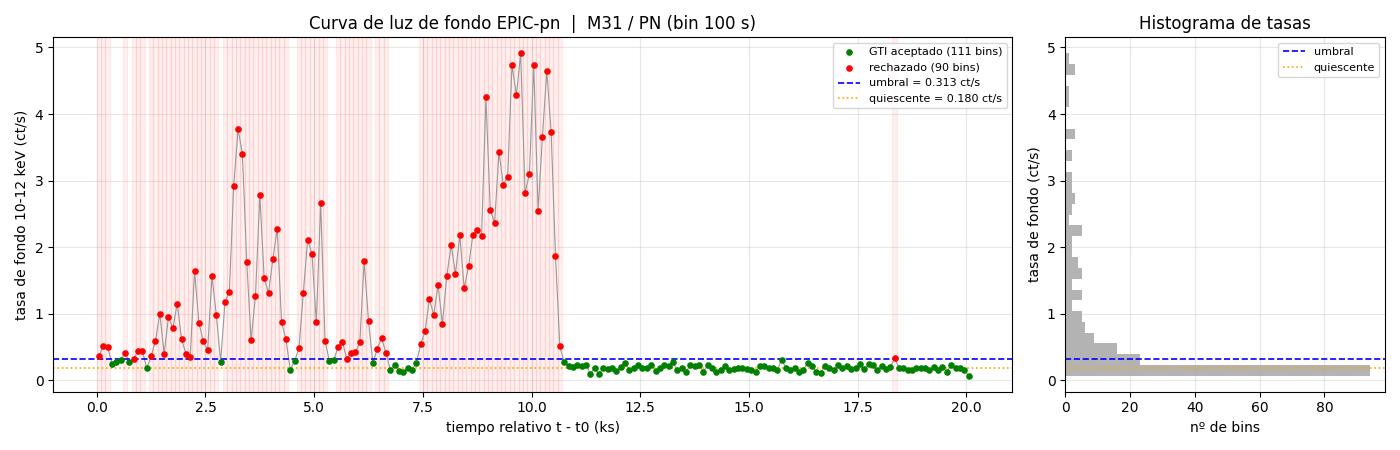

In [9]:
# ---- Diagnostico grafico del filtro de fondo (2 paneles) ----
if gti_diag is not None:
    d = gti_diag
    rates = d["rates"]; good_bins = d["good_bins"]
    thr = d["threshold"]; quiescent = d["quiescent_rate"]
    t_rel_ks = (d["bin_centers"] - d["t0"]) / 1000.0     # tiempo relativo en ks
    bin_ks = d["bin_seconds"] / 1000.0

    figb, (axL, axH) = plt.subplots(1, 2, figsize=(14, 4.5),
                                    gridspec_kw={'width_ratios': [3, 1]})

    # Panel A: curva de tasa de fondo vs tiempo (ks)
    axL.plot(t_rel_ks, rates, color='0.6', lw=0.8, zorder=1)
    axL.scatter(t_rel_ks[good_bins], rates[good_bins], s=14, c='green',
                label='GTI aceptado ({0} bins)'.format(d["n_good_bins"]), zorder=3)
    axL.scatter(t_rel_ks[~good_bins], rates[~good_bins], s=14, c='red',
                label='rechazado ({0} bins)'.format(d["n_rejected_bins"]), zorder=3)
    # sombreado de intervalos rechazados
    for xc, gb in zip(t_rel_ks, good_bins):
        if not gb:
            axL.axvspan(xc - bin_ks / 2, xc + bin_ks / 2, color='red', alpha=0.06, zorder=0)
    axL.axhline(thr, color='blue', ls='--', lw=1.2,
                label='umbral = {0:.3f} ct/s'.format(thr))
    axL.axhline(quiescent, color='orange', ls=':', lw=1.2,
                label='quiescente = {0:.3f} ct/s'.format(quiescent))
    axL.set_xlabel('tiempo relativo t - t0 (ks)')
    axL.set_ylabel('tasa de fondo 10-12 keV (ct/s)')
    axL.set_title('Curva de luz de fondo EPIC-pn  |  {0} / {1} (bin {2} s)'.format(
        OBJECT, INST, d["bin_seconds"]))
    axL.legend(fontsize=8, loc='best')
    axL.grid(alpha=0.3)

    # Panel B: histograma de tasas
    axH.hist(rates, bins=30, orientation='horizontal', color='0.7')
    axH.axhline(thr, color='blue', ls='--', lw=1.2, label='umbral')
    axH.axhline(quiescent, color='orange', ls=':', lw=1.2, label='quiescente')
    axH.set_xlabel('nº de bins')
    axH.set_ylabel('tasa de fondo (ct/s)')
    axH.set_title('Histograma de tasas')
    axH.legend(fontsize=8, loc='best')
    axH.grid(alpha=0.3)

    figb.tight_layout()
    plt.show()

Regions

In [10]:
# Loading regions detected from SAS
regions = []
regions_radec = Regions.read(region_list, format="ds9")
for region in regions_radec:
    regions.append(region.to_pixel(w))

len(regions)

173

---
## Pipeline de detección HDBSCAN

A partir de `goodEvents` (ya filtrado por FLAG/PATTERN/PI científico y por el GTI
 temporal de fondo), este pipeline:

1. Aplica una exclusión **opcional** de rangos de PI, sin usar PI como dimensión del clústering.
2. Agrupa por densidad en `spatiotemporal` por defecto (X/Y/TIME con escalas físicas) o, si se desea, en modo `spatial` (espacio de cielo X/Y).
3. Utiliza el perfil de hiperparámetros **B_recall_plus** en el pipeline final.
4. Procesa cada CCD por separado y reconstruye la asociación global por índices (`-1` = ruido).
5. Filtra los clústeres por calidad mediante persistencia, probabilidad media y número mínimo de eventos.
6. Construye regiones circulares a partir del centro mediano y del radio p90, acotados entre límites mínimo y máximo en arcsec.
7. Evalúa la concordancia frente a SAS mediante emparejamiento 1-a-1 con algoritmo húngaro sobre separaciónes angulares.

Las posiciones SAS se utilizan **solo para evaluación** y no intervienen en la etapa de clústering.


#### Exclusion opcional de rangos de PI

`EXCLUDE_PI_RANGES` permite descartar intervalos de energía problematicos (p.ej.
lineas instrumentales) **despues** del GTI y **antes** del clústering. Por defecto
está vacío (no excluye nada). PI se usa solo como filtro; **nunca** entra como
dimension euclidea del clústering.

In [11]:
# Rangos de PI (eV) a excluir tras el GTI y antes del clústering. Vacio = sin exclusion.
EXCLUDE_PI_RANGES = []   # p.ej. [(1450, 1600), (7000, 8000)]

def apply_pi_exclusion(ev, pi_ranges):
    """Devuelve el subconjunto de eventos cuyo PI NO cae en ninguno de los rangos dados.
    No modifica ni usa PI como dimension de clústering; solo filtra filas."""
    if not pi_ranges:
        return ev
    pi = np.asarray(ev.PI, dtype=float)
    keep_mask = np.ones(len(pi), dtype=bool)
    for lo, hi in pi_ranges:
        keep_mask &= ~((pi >= lo) & (pi <= hi))
    return ev[keep_mask]

clusterEvents = apply_pi_exclusion(goodEvents, EXCLUDE_PI_RANGES)
print("Eventos para clústering: {0}  (excluidos por PI: {1})".format(
    len(clusterEvents), len(goodEvents) - len(clusterEvents)))

Eventos para clústering: 167401  (excluidos por PI: 0)


#### Configuración de deteccion

Parametros fijos (no dependen del nº de eventos ni se sobrescriben). El modo
`spatiotemporal` es el configurado por defecto. En este modo el tiempo se
escala con `TIME_SCALE_SECONDS` y se pondera con `TIME_WEIGHT<1` para que la
proximidad temporal pese menos que la espacial (no es un MinMax de igual peso).
El modo `spatial` queda disponible como alternativa de comparación. Los filtros
de calidad **deben calibrarse** segun el campo/observación.

In [12]:
# ---- Modo de detección ----
# Se define el espacio de clústering principal. El modo espacial utiliza X/Y de cielo;
# el modo espaciotemporal añade TIME con una escala física controlada.
DETECTION_MODE = 'spatiotemporal'   # modo por defecto; 'spatiotemporal' (X/Y/TIME) | 'spatial' (X/Y)

# ---- Escalas espaciales (isótropas y comunes a X e Y) ----
# Se normalizan las distancias espaciales con un radio característico comparable a la PSF.
ARCSEC_PER_PIX = abs(REFXCDLT) * 3600.0
PSF_RADIUS_PIX = 6.0 / ARCSEC_PER_PIX    # ~PSF EPIC-pn: unidad de distancia espacial

# ---- Escala temporal (solo en modo espaciotemporal) ----
# Se controla la contribución relativa del tiempo al clústering.
TIME_SCALE_SECONDS = 5000.0          # 1 unidad temporal = 5000 s
TIME_WEIGHT = 0.2                    # peso relativo del eje temporal (<1)

# ---- Perfil nominal de hiperparámetros HDBSCAN ----
# Se fija el perfil B_recall_plus como configuración activa del pipeline final.
HYPERPARAMETER_PROFILE = 'B_recall_plus'
cluster_selection_method = 'eom'
metric = 'euclidean'
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES = 15
RUN_LEAF_COMPARISON = False          # La comparación con 'leaf' se mantiene desactivada por defecto.

# ---- Filtros de calidad de detección ----
# Se aceptan solo clústeres con estabilidad mínima, pertenencia media suficiente
# y un número de eventos compatible con una detección útil.
MIN_PERSISTENCE = 0.03
MIN_MEAN_PROBABILITY = 0.08
MIN_CLUSTER_EVENTS = 40

# ---- Regiones ----
# Se imponen límites físicos al radio para evitar regiones degeneradas o excesivamente extensas.
MIN_RADIUS_ARCSEC = 6.0
MAX_RADIUS_ARCSEC = 60.0
MIN_RADIUS_PX = MIN_RADIUS_ARCSEC / ARCSEC_PER_PIX
MAX_RADIUS_PX = MAX_RADIUS_ARCSEC / ARCSEC_PER_PIX

# ---- Validación ----
# La coincidencia frente a SAS se acepta solo dentro de esta tolerancia angular.
MATCH_TOLERANCE_ARCSEC = 15.0

print('Modo:', DETECTION_MODE, '| arcsec/pix:', round(ARCSEC_PER_PIX, 4))
print('Perfil HDBSCAN:', HYPERPARAMETER_PROFILE)
print('PSF_RADIUS_PIX:', round(PSF_RADIUS_PIX, 2),
      '| MIN/MAX radio px:', round(MIN_RADIUS_PX, 1), round(MAX_RADIUS_PX, 1))
print('min_cluster_size:', MIN_CLUSTER_SIZE, '| min_samples:', MIN_SAMPLES,
      '| método:', cluster_selection_method)
print('Filtros calidad -> persistencia >=', MIN_PERSISTENCE,
      '| prob_media >=', MIN_MEAN_PROBABILITY,
      '| n_eventos >=', MIN_CLUSTER_EVENTS)


Modo: spatiotemporal | arcsec/pix: 0.05
Perfil HDBSCAN: B_recall_plus
PSF_RADIUS_PIX: 120.0 | MIN/MAX radio px: 120.0 1200.0
min_cluster_size: 30 | min_samples: 15 | método: eom
Filtros calidad -> persistencia >= 0.03 | prob_media >= 0.08 | n_eventos >= 40


#### Construccion de variables

Se usan las posiciones de **cielo** `X`,`Y` (isotropas, mismo CDELT) divididas por
`PSF_RADIUS_PIX` para obtener distancias en unidades de PSF. El clústering y la
construcción de regiones ocurren en el **mismo** sistema X/Y (no hay MinMax
independiente por eje). En la configuración actual se añade tiempo por defecto,
al usar el modo spatiotemporal.

In [13]:
event_ccd  = np.asarray(clusterEvents.CCDNR, dtype=int)
sky_X      = np.asarray(clusterEvents.X, dtype=float)
sky_Y      = np.asarray(clusterEvents.Y, dtype=float)
event_time = np.asarray(clusterEvents.TIME, dtype=float)

# Escala espacial isotropa comun (misma unidad en X e Y)
xs = sky_X / PSF_RADIUS_PIX
ys = sky_Y / PSF_RADIUS_PIX

# Escala temporal (solo spatiotemporal): centrada y ponderada
t0 = event_time.min()
ts = (event_time - t0) / TIME_SCALE_SECONDS * TIME_WEIGHT

def features_for(idx):
    """Matriz de caracteristicas para los indices dados, segun DETECTION_MODE."""
    if DETECTION_MODE == 'spatiotemporal':
        return np.column_stack((xs[idx], ys[idx], ts[idx]))
    return np.column_stack((xs[idx], ys[idx]))

print("CCDs presentes:", sorted(set(event_ccd.tolist())))
print("Rango X:", sky_X.min(), sky_X.max(), "| Rango Y:", sky_Y.min(), sky_Y.max())

CCDs presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Rango X: 8520.0 43855.0 | Rango Y: 5589.0 40658.0


In [14]:
def cluster_ccd(ccd):
    """Se ejecuta HDBSCAN sobre los eventos de un CCD (1..12).
    Se devuelven (indices_globales, labels, probabilities, persistencias).
    La etiqueta -1 representa ruido, siguiendo la convención de HDBSCAN."""
    idx = np.where(event_ccd == ccd)[0]
    if len(idx) < MIN_CLUSTER_SIZE:
        return idx, np.full(len(idx), -1, dtype=int), np.zeros(len(idx)), np.array([])
    clusterer = hdbscan.HDBSCAN(
        cluster_selection_method=cluster_selection_method,
        metric=metric,
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        core_dist_n_jobs=NUMTHREADS)
    clusterer.fit(features_for(idx))
    return (idx, clusterer.labels_, clusterer.probabilities_,
            clusterer.cluster_persistence_)


In [15]:
_t0 = t.time()
with Pool(NUMTHREADS) as pool_cluster:
    per_ccd_results = pool_cluster.map(cluster_ccd, range(1, 13))
elapsed = t.time() - _t0
print("Clustering ({0}) en {1:.1f}s".format(DETECTION_MODE, elapsed))

# Ensamblado robusto por indices: etiqueta global por evento (-1 = ruido)
global_label = np.full(len(event_ccd), -1, dtype=int)
global_prob  = np.zeros(len(event_ccd))
# results[k] corresponde al CCD (k+1)
raw_clusters_per_ccd = []
for k, (idx, labels, probs, pers) in enumerate(per_ccd_results):
    n_here = int(labels.max() + 1) if len(labels) and labels.max() >= 0 else 0
    raw_clusters_per_ccd.append(n_here)

Clustering (spatiotemporal) en 3.8s


#### Construccion de regiones y filtros de calidad

Por cada clúster (label >= 0) de cada CCD se calcula el centro **mediano** en X/Y
y el radio como percentil 90 de las distancias al centro, recortado a
`[MIN_RADIUS_PX, MAX_RADIUS_PX]`. Los clústers degenerados (radio nulo/< min) se
fijan al radio mínimo; los saturados (>= max) se reportan. Se aplican los filtros
de calidad (persistencia, probabilidad media, nº de eventos). Se mantienen dos
catalogos: **aceptados** (pasan los filtros) y **todos** (crudos)."""

In [16]:
def build_region(members):
    """Centro mediano y radio p90 (px) para los eventos miembro (indices globales).
    Devuelve (cx, cy, radius_px, saturated_bool, degenerate_bool)."""
    pts = np.unique(np.column_stack((sky_X[members], sky_Y[members])), axis=0)
    cx, cy = np.median(pts[:, 0]), np.median(pts[:, 1])
    saturated = False
    degenerate = False
    if len(pts) < 3:
        r = MIN_RADIUS_PX
        degenerate = True
    else:
        d = np.hypot(pts[:, 0] - cx, pts[:, 1] - cy)
        r = np.percentile(d, 90)
    if r < MIN_RADIUS_PX:
        r = MIN_RADIUS_PX
        degenerate = True
    if r > MAX_RADIUS_PX:
        r = MAX_RADIUS_PX
        saturated = True
    return cx, cy, r, saturated, degenerate

accepted_records = []   # dicts de clústers que pasan filtros de calidad
all_records = []        # dicts de todos los clústers crudos
raw_global_id = 0       # identificador inequivoco para clústers crudos
global_id = 0           # identificador inequivoco para clústers aceptados
n_saturated = 0

for k, (idx, labels, probs, pers) in enumerate(per_ccd_results):
    ccd = k + 1
    n_here = int(labels.max() + 1) if len(labels) and labels.max() >= 0 else 0
    for L in range(n_here):
        sel = labels == L
        members = idx[sel]
        n_ev = int(sel.sum())
        mean_p = float(probs[sel].mean()) if n_ev else 0.0
        min_p = float(probs[sel].min()) if n_ev else 0.0
        persistence = float(pers[L]) if L < len(pers) else 0.0
        cx, cy, r, sat, degen = build_region(members)

        rec = dict(
            ccd=ccd,
            local_label=L,
            raw_global_id=raw_global_id,
            members=members.copy(),
            n_events=n_ev,
            mean_prob=mean_p,
            min_prob=min_p,
            persistence=persistence,
            cx=cx,
            cy=cy,
            radius_px=r,
            saturated=sat,
            degenerate=degen,
        )
        all_records.append(rec)
        raw_global_id += 1

        # Filtros de calidad (deben calibrarse por campo)
        if (persistence >= MIN_PERSISTENCE and mean_p >= MIN_MEAN_PROBABILITY
                and n_ev >= MIN_CLUSTER_EVENTS):
            rec_acc = dict(rec, global_id=global_id)
            accepted_records.append(rec_acc)
            global_label[members] = global_id
            global_prob[members] = probs[sel]
            global_id += 1
            if sat:
                n_saturated += 1

print("Clusters crudos (todos):", len(all_records))
print("Clusters aceptados      :", len(accepted_records))
print("Saturados (radio=max)   :", n_saturated)


Clusters crudos (todos): 390
Clusters aceptados      : 92
Saturados (radio=max)   : 7


In [17]:
# Diagnostico por CCD
print("{:>4} {:>8} {:>7} {:>8} {:>9}".format("CCD", "eventos", "ruido", "crudos", "aceptados"))
for k, (idx, labels, probs, pers) in enumerate(per_ccd_results):
    ccd = k + 1
    n_ev = len(idx)
    n_noise = int((labels == -1).sum()) if len(labels) else 0
    n_raw = raw_clusters_per_ccd[k]
    n_acc = sum(1 for r in accepted_records if r["ccd"] == ccd)
    print("{:>4} {:>8} {:>7} {:>8} {:>9}".format(ccd, n_ev, n_noise, n_raw, n_acc))

print("\nTotales: eventos={0}  ruido={1}  crudos={2}  aceptados={3}".format(
    len(event_ccd), int((global_label == -1).sum()),
    len(all_records), len(accepted_records)))

 CCD  eventos   ruido   crudos aceptados
   1    17801    8043       38        13
   2     4436    2577       23         9
   3     2647    1503        8         3
   4    63584   30425       98        12
   5    11535    5444       40         9
   6     4350    2524       19         2
   7    21760   11687       53        13
   8    13026    5365       30         7
   9     6008    2822       16         4
  10    13468    5093       32        10
  11     5789    2469       20         5
  12     2997    1644       13         5

Totales: eventos=167401  ruido=101664  crudos=390  aceptados=92


In [18]:
# Distribucion de tamaños, persistencia, probabilidad y radios (aceptados)
if accepted_records:
    sizes = np.array([r["n_events"] for r in accepted_records])
    perss = np.array([r["persistence"] for r in accepted_records])
    mprob = np.array([r["mean_prob"] for r in accepted_records])
    radii_as = np.array([r["radius_px"] for r in accepted_records]) * ARCSEC_PER_PIX
    def _stats(name, a, fmt="{:.3f}"):
        print(("{:<12} min="+fmt+"  mediana="+fmt+"  max="+fmt).format(
            name, a.min(), np.median(a), a.max()))
    _stats("eventos", sizes, "{:.0f}")
    _stats("persistencia", perss)
    _stats("prob.media", mprob)
    _stats("radio[\"]", radii_as, "{:.1f}")
else:
    print("Sin clústers aceptados: revisar filtros de calidad / parámetros.")

eventos      min=46  mediana=268  max=15564
persistencia min=0.030  mediana=0.068  max=0.378
prob.media   min=0.441  mediana=0.657  max=0.989
radio["]     min=6.6  mediana=21.8  max=60.0


#### Escritura de catalogos DS9

- `hdbscan_region_list`  ← clústers **aceptados** (rojo).
- `hdbscan_region_list_all` ← **todos** los clústers crudos (naranja).

Las rutas son relativas (definidas al inicio del notebook).

In [19]:
def _to_sky_circle(cx, cy, r_px, color):
    pix = CirclePixelRegion(center=PixCoord(x=cx, y=cy), radius=r_px)
    sky = pix.to_sky(w)
    sky.visual["color"] = color
    return sky

accepted_sky = [_to_sky_circle(r["cx"], r["cy"], r["radius_px"], "red")
                for r in accepted_records]
all_sky = [_to_sky_circle(r["cx"], r["cy"], r["radius_px"], "orange")
           for r in all_records]

if accepted_sky:
    Regions(accepted_sky).write(hdbscan_region_list, format="ds9", overwrite=True)
    print("Escrito (aceptados):", hdbscan_region_list, "->", len(accepted_sky))
if all_sky:
    Regions(all_sky).write(hdbscan_region_list_all, format="ds9", overwrite=True)
    print("Escrito (todos)    :", hdbscan_region_list_all, "->", len(all_sky))

Escrito (aceptados): ../dataset/0405320501/pps\P0405320501EPX000HDBSCANREG.ASC -> 92
Escrito (todos)    : ../dataset/0405320501/pps\P0405320501EPX001HDBSCANREG.ASC -> 390


In [20]:
# Carga de las regiones HDBSCAN aceptadas (para validación/plot)
regionsh = []
regionsh_radec = []
if accepted_sky:
    regionsh_radec = Regions.read(hdbscan_region_list, format="ds9")
    for region in regionsh_radec:
        regionsh.append(region.to_pixel(w))
print("Regiones HDBSCAN aceptadas cargadas:", len(regionsh))

Regiones HDBSCAN aceptadas cargadas: 92


In [21]:
# Limites de ejes a partir de las posiciones de cielo
x_min, x_max = sky_X.min(), sky_X.max()
y_min, y_max = sky_Y.min(), sky_Y.max()
pad_x = 0.02 * (x_max - x_min)
pad_y = 0.02 * (y_max - y_min)

#### Visualizacion: eventos + regiones SAS (negro) vs HDBSCAN (rojo)

Se dibujan **todas** las regiones SAS y **todas** las HDBSCAN aceptadas. Los eventos se muestrean solo para el graficado.

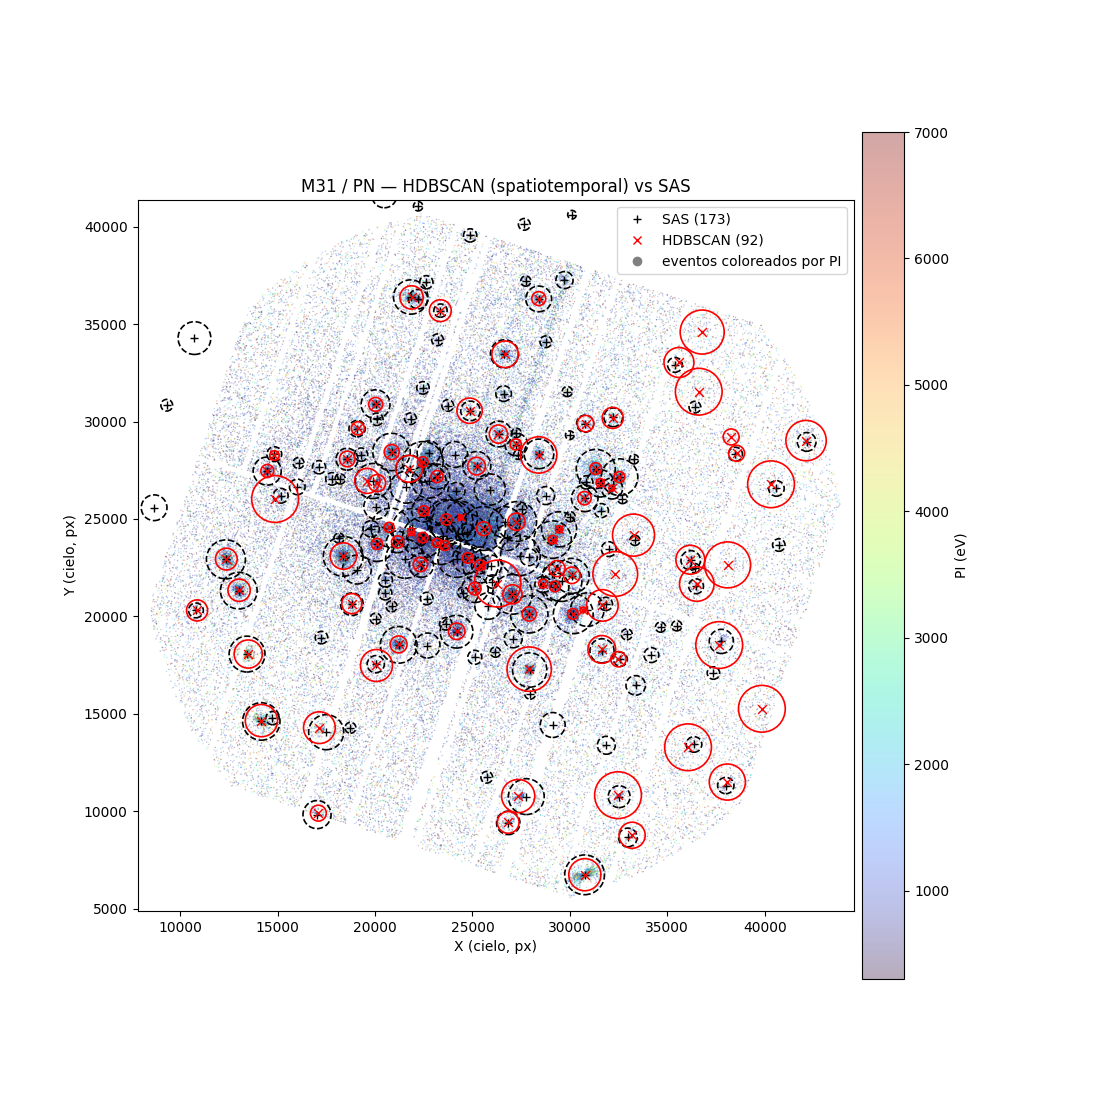

In [22]:
fig, ax = plt.subplots(figsize=(11, 11))

# Eventos (muestreados solo para dibujar)
MAX_PLOT = 200000
if len(sky_X) > MAX_PLOT:
    sidx = np.random.default_rng(0).choice(len(sky_X), MAX_PLOT, replace=False)
else:
    sidx = np.arange(len(sky_X))

pi_vals_plot = np.asarray(clusterEvents.PI, dtype=float)
sc = ax.scatter(
    sky_X[sidx], sky_Y[sidx], s=1,
    c=pi_vals_plot[sidx], cmap='turbo', alpha=0.35,
    linewidths=0, vmin=PIMIN, vmax=PIMAX
)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('PI (eV)')

# Regiones SAS (verde) - todas
for reg in regions:
    ax.add_patch(plt.Circle((reg.center.x, reg.center.y), reg.radius,
                            fill=False, edgecolor='black', linestyle='--', linewidth=1.2))
sas_cx = [reg.center.x for reg in regions]
sas_cy = [reg.center.y for reg in regions]
ax.scatter(sas_cx, sas_cy, marker='+', c='black', s=40, linewidths=1.0)

# Regiones HDBSCAN (rojo) - todas las aceptadas
for reg in regionsh:
    ax.add_patch(plt.Circle((reg.center.x, reg.center.y), reg.radius,
                            fill=False, edgecolor='red', linewidth=1.2))
hdb_cx = [reg.center.x for reg in regionsh]
hdb_cy = [reg.center.y for reg in regionsh]
ax.scatter(hdb_cx, hdb_cy, marker='x', c='red', s=40, linewidths=1.0)
legend_elems = [
    Line2D([0], [0], marker='+', color='black', linestyle='None', label='SAS (%d)' % len(regions)),
    Line2D([0], [0], marker='x', color='red', linestyle='None', label='HDBSCAN (%d)' % len(regionsh)),
    Line2D([0], [0], marker='o', color='gray', linestyle='None', label='eventos coloreados por PI'),
]
ax.legend(handles=legend_elems, loc='upper right')
ax.set_xlim(x_min - pad_x, x_max + pad_x)
ax.set_ylim(y_min - pad_y, y_max + pad_y)
ax.set_aspect('equal')
ax.set_xlabel('X (cielo, px)'); ax.set_ylabel('Y (cielo, px)')
ax.set_title('{0} / {1} — HDBSCAN ({2}) vs SAS'.format(OBJECT, INST, DETECTION_MODE))
plt.show()


#### Validación 1-a-1 (matching hungaro sobre separaciónes angulares)

Se emparejan centros SAS y HDBSCAN minimizando la separación angular total
(`linear_sum_assignment`). Un par cuenta como TP si su separación <=
`MATCH_TOLERANCE_ARCSEC`. Se reportan TP/FP/FN, precision, recall, F1 y las
distancias de emparejamiento.

In [23]:
def validate(sas_regions_sky, hdb_regions_pix):
    n_sas = len(sas_regions_sky)
    n_hdb = len(hdb_regions_pix)
    if n_sas == 0 or n_hdb == 0:
        return dict(TP=0, FP=n_hdb, FN=n_sas, precision=0.0, recall=0.0,
                    F1=0.0, distances=[])
    sas = SkyCoord([r.center for r in sas_regions_sky])
    hcx = np.array([r.center.x for r in hdb_regions_pix])
    hcy = np.array([r.center.y for r in hdb_regions_pix])
    hsky = w.pixel_to_world(hcx, hcy)
    cost = np.zeros((n_sas, n_hdb))
    for i in range(n_sas):
        cost[i, :] = sas[i].separation(hsky).arcsec
    row, col = linear_sum_assignment(cost)
    dists = [cost[r, c] for r, c in zip(row, col)]
    TP = int(sum(1 for d in dists if d <= MATCH_TOLERANCE_ARCSEC))
    matched = [d for d in dists if d <= MATCH_TOLERANCE_ARCSEC]
    FP = n_hdb - TP
    FN = n_sas - TP
    P = TP / (TP + FP) if (TP + FP) else 0.0
    R = TP / (TP + FN) if (TP + FN) else 0.0
    F1 = 2 * P * R / (P + R) if (P + R) else 0.0
    return dict(TP=TP, FP=FP, FN=FN, precision=P, recall=R, F1=F1, distances=matched)

res = validate(regions_radec, regionsh)
print("SAS: {0}  HDBSCAN: {1}".format(len(regions_radec), len(regionsh)))
print("TP={TP}  FP={FP}  FN={FN}".format(**res))
print("precision={precision:.3f}  recall={recall:.3f}  F1={F1:.3f}".format(**res))
if res["distances"]:
    dd = np.array(res["distances"])
    print("Distancias TP (\"): mediana={0:.2f}  max={1:.2f}".format(np.median(dd), dd.max()))

SAS: 173  HDBSCAN: 92
TP=78  FP=14  FN=95
precision=0.848  recall=0.451  F1=0.589
Distancias TP ("): mediana=1.58  max=14.75


In [24]:
# (Opcional / referencia) Metrica antigua: centro SAS contenido en alguna region HDBSCAN.
# No es 1-a-1 y puede sobrecontar; se deja solo como comparación.
def old_metric(sas_sky, hdb_pix):
    if not hdb_pix:
        return 0
    hcx = np.array([r.center.x for r in hdb_pix])
    hcy = np.array([r.center.y for r in hdb_pix])
    hr = np.array([r.radius for r in hdb_pix])
    sas_pix = [r.to_pixel(w) for r in sas_sky]
    hits = 0
    for s in sas_pix:
        d = np.hypot(hcx - s.center.x, hcy - s.center.y)
        if np.any(d <= hr):
            hits += 1
    return hits

print("(Referencia) centros SAS dentro de alguna region HDBSCAN:",
      old_metric(regions_radec, regionsh), "/", len(regions_radec))

(Referencia) centros SAS dentro de alguna region HDBSCAN: 91 / 173


#### Comparación opcional con `clúster_selection_method='leaf'`

La comparación se mantiene desactivada por defecto (`RUN_LEAF_COMPARISON=False`).
El criterio `leaf` tiende a fragmentar más la estructura densa y, en muchos campos,
a incrementar el número de regiones candidatas y de falsos positivos.


In [25]:
if RUN_LEAF_COMPARISON:
    def cluster_leaf(ccd):
        """Se estima el número de clústeres crudos por CCD usando `leaf`.
        Esta rutina se utiliza solo con fines comparativos."""
        idx = np.where(event_ccd == ccd)[0]
        if len(idx) < MIN_CLUSTER_SIZE:
            return 0
        cl = hdbscan.HDBSCAN(cluster_selection_method='leaf', metric=metric,
                             min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                             core_dist_n_jobs=NUMTHREADS).fit(features_for(idx))
        return int(cl.labels_.max() + 1)

    total_leaf = sum(cluster_leaf(c) for c in range(1, 13))
    print('Clústeres totales con leaf:', total_leaf,
          '| eom (crudos):', len(all_records))
else:
    print('Comparación leaf desactivada (RUN_LEAF_COMPARISON=False).')


Comparación leaf desactivada (RUN_LEAF_COMPARISON=False).


## Barrido exploratorio de hiperparámetros

Estas celdas preservan el barrido antiguo como bloque **opcional** y separado del pipeline final.
Se utilizan únicamente para explorar la sensibilidad de `min_clúster_size`, `min_samples`
y `clúster_selection_method`. La configuración nominal activa sigue siendo **B_recall_plus**
y no se modifica salvo que se active explícitamente `RUN_HYPERPARAMETER_SWEEP=True`.


In [26]:
# ---- Barrido exploratorio de hiperparámetros (opcional) ----
# Este bloque no altera el pipeline nominal. Se conserva para análisis de sensibilidad.
RUN_HYPERPARAMETER_SWEEP = False
SWEEP_CLUSTER_SELECTION_METHODS = ['eom', 'leaf']
SWEEP_MIN_CLUSTER_SIZES = [20, 30, 40, 60, 80]
SWEEP_MIN_SAMPLES = [10, 15, 20, 30]
SWEEP_MAX_CCDS = 12

def _count_clusters_for_params(ccd, min_cluster_size, min_samples, cluster_method):
    """Se cuenta el número de clústeres crudos para una combinación dada de parámetros."""
    idx = np.where(event_ccd == ccd)[0]
    if len(idx) < min_cluster_size:
        return dict(n_clusters=0, n_noise=len(idx), n_events=len(idx))
    cl = hdbscan.HDBSCAN(
        cluster_selection_method=cluster_method,
        metric=metric,
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        core_dist_n_jobs=NUMTHREADS
    ).fit(features_for(idx))
    labels = cl.labels_
    n_clusters = int(labels.max() + 1) if len(labels) and labels.max() >= 0 else 0
    n_noise = int(np.sum(labels < 0))
    return dict(n_clusters=n_clusters, n_noise=n_noise, n_events=len(idx))

if RUN_HYPERPARAMETER_SWEEP:
    sweep_rows = []
    for cluster_method in SWEEP_CLUSTER_SELECTION_METHODS:
        for mcs in SWEEP_MIN_CLUSTER_SIZES:
            for ms in SWEEP_MIN_SAMPLES:
                total_clusters = 0
                total_noise = 0
                total_events = 0
                per_ccd_counts = []
                for ccd in range(1, SWEEP_MAX_CCDS + 1):
                    res = _count_clusters_for_params(ccd, mcs, ms, cluster_method)
                    total_clusters += res['n_clusters']
                    total_noise += res['n_noise']
                    total_events += res['n_events']
                    per_ccd_counts.append(res['n_clusters'])
                noise_fraction = (total_noise / total_events) if total_events else np.nan
                sweep_rows.append((cluster_method, mcs, ms, total_clusters, total_noise,
                                   total_events, noise_fraction, per_ccd_counts))

    sweep_rows = sorted(sweep_rows, key=lambda x: (x[0], x[3], -x[1], -x[2]))
    print('method | min_cluster_size | min_samples | total_clusters | noise_fraction')
    for row in sweep_rows:
        print('{:>4s} | {:>16d} | {:>11d} | {:>14d} | {:.3f}'.format(
            row[0], row[1], row[2], row[3], row[6]))
else:
    print('Barrido de hiperparámetros desactivado (RUN_HYPERPARAMETER_SWEEP=False).')


Barrido de hiperparámetros desactivado (RUN_HYPERPARAMETER_SWEEP=False).


In [27]:
# Eventos científicos eliminados por GTI: pasan FLAG/PI/PATTERN, pero caen en bins temporales rechazados
time_vals = np.asarray(clusterEvents.TIME, dtype=float)

if gti_diag is not None:
    sci_mask_full = (
        (np.asarray(evList.FLAG) == 0) &
        (np.asarray(evList.PI) >= PIMIN) &
        (np.asarray(evList.PI) <= PIMAX) &
        (np.asarray(evList.PATTERN) <= 4)
    )
    gti_mask_full = np.asarray(gti_diag['gti_mask'], dtype=bool)

    removed_by_gti_mask = sci_mask_full & (~gti_mask_full)
    removedByGTIEvents = evList[removed_by_gti_mask]

    removed_rawx_vals = np.asarray(removedByGTIEvents.RAWX, dtype=float)
    removed_rawy_vals = np.asarray(removedByGTIEvents.RAWY, dtype=float)
    removed_time_vals = np.asarray(removedByGTIEvents.TIME, dtype=float)
    removed_t_rel = removed_time_vals - time_vals.min()

    removed_ccd_vals = np.asarray(removedByGTIEvents.CCDNR, dtype=int)
    removed_pi_vals = np.asarray(removedByGTIEvents.PI, dtype=float)

    print("Eventos científicos eliminados por GTI:", len(removedByGTIEvents))
else:
    removedByGTIEvents = None
    removed_rawx_vals = np.array([], dtype=float)
    removed_rawy_vals = np.array([], dtype=float)
    removed_time_vals = np.array([], dtype=float)
    removed_t_rel = np.array([], dtype=float)
    removed_ccd_vals = np.array([], dtype=int)
    removed_pi_vals = np.array([], dtype=float)
    print("No hay gti_diag disponible; no se puede construir el contexto eliminado por GTI.")

Eventos científicos eliminados por GTI: 432929


## Selector interactivo de clústeres y visualización de detalle

Este bloque añade una selección interactiva por clic sobre el mapa 2D del cielo.
Se puede inspeccionar cualquier clúster aceptado y, de forma opcional, cualquier clúster crudo.
La figura de detalle combina una vista 2D en coordenadas de cielo con una vista 3D en
RAWX/RAWY/TIME. La selección por clic se realiza sobre los centros de las regiones aceptadas.


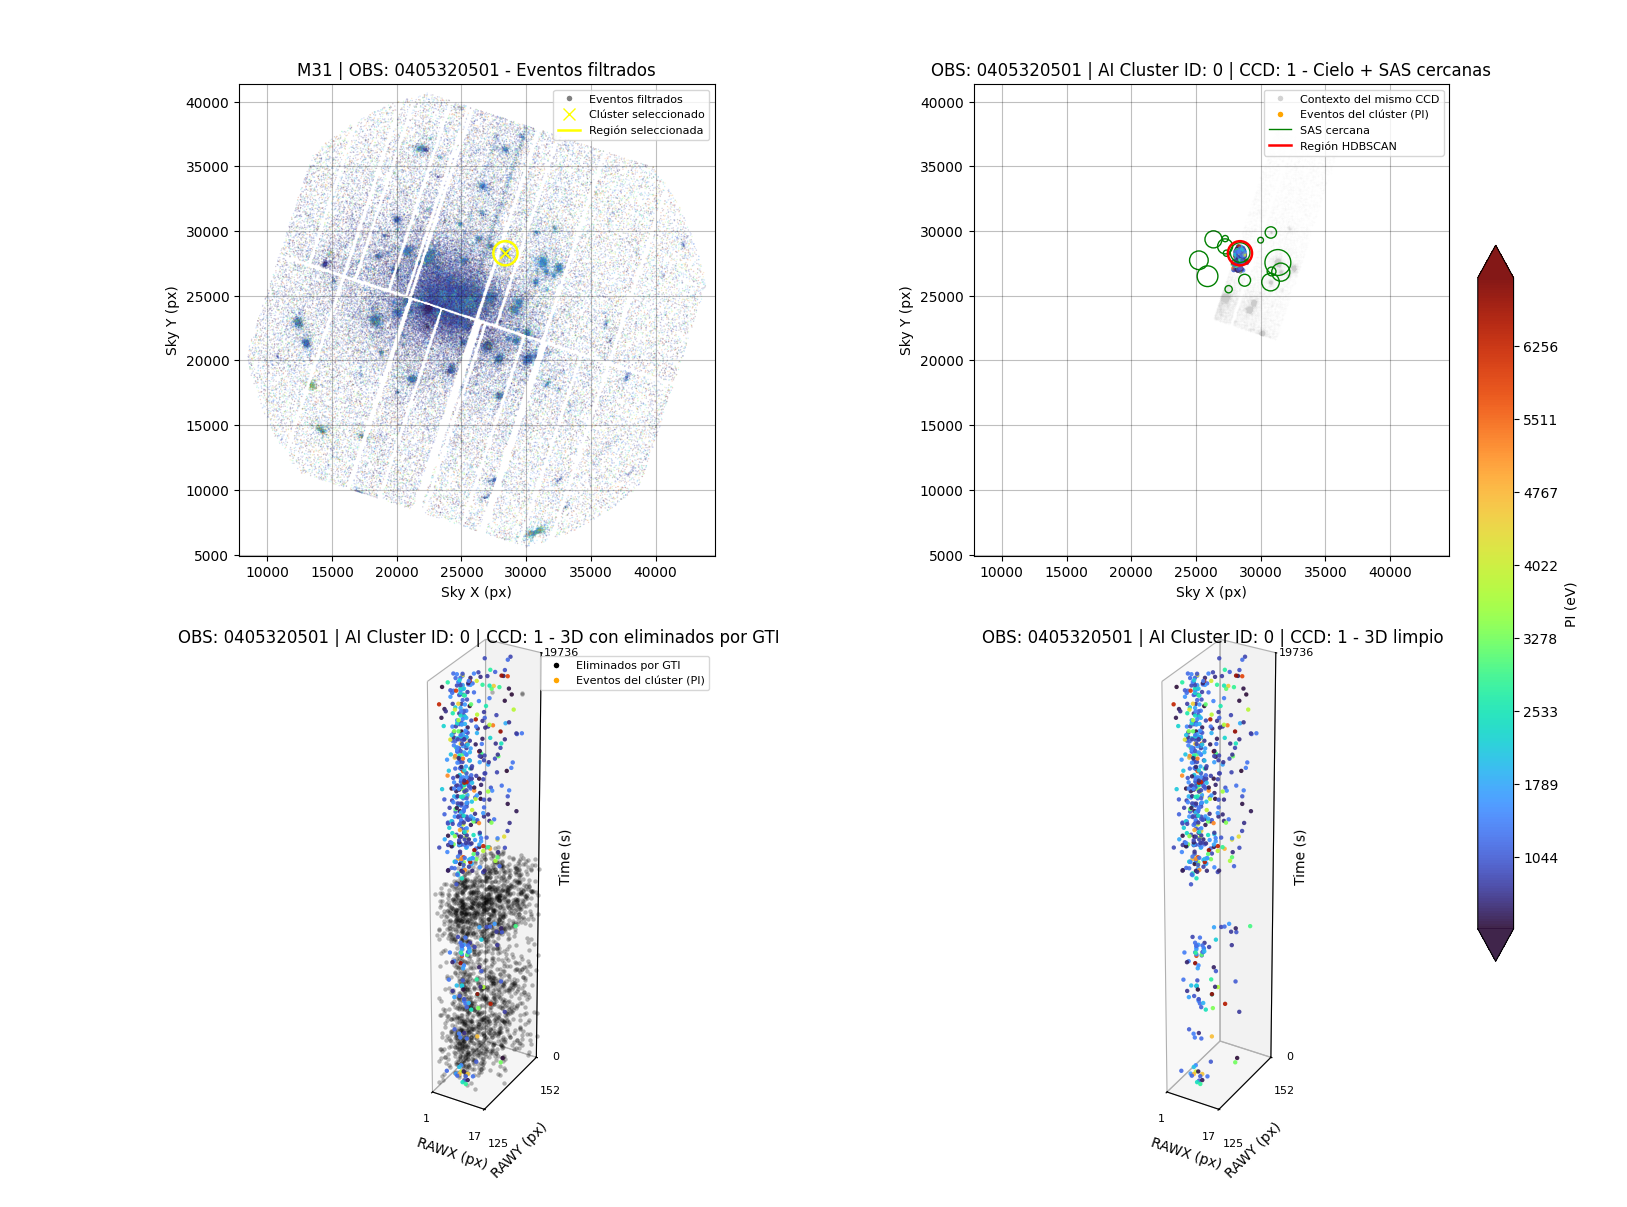

Selector por clic activado. Se recomienda usar un backend interactivo de Matplotlib.


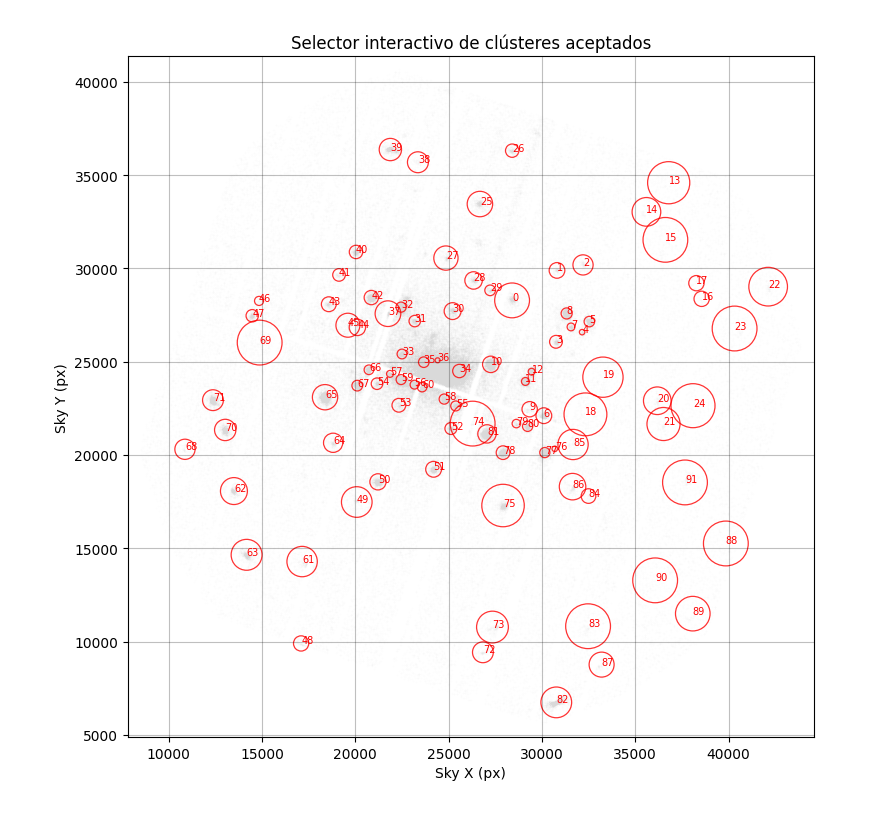

In [28]:
# -----------------------------
# Parámetros del selector interactivo
# -----------------------------
VIS_MODE = 'accepted'  # 'accepted' | 'raw'
TARGET_ID = 0          # Se utiliza como selección inicial.
SAS_SELECTION = 'nearest'  # 'nearest' | 'all'
N_SAS_REGIONS = 70
N_NEAREST_SAS = 15
AX_PLOT_SIZE = 10
FIG_SCALE = 1.05
USE_LOG_PI = False
SHOW_CONTEXT = True
CONTEXT_ALPHA = 0.03
ELEV = 30
AZIM = -60
ENABLE_CLICK_SELECTOR = True
CLICK_MAX_DISTANCE_PX = 80.0

pi_vals = np.asarray(clusterEvents.PI, dtype=float)
rawx_vals = np.asarray(clusterEvents.RAWX, dtype=float)
rawy_vals = np.asarray(clusterEvents.RAWY, dtype=float)
time_vals = np.asarray(clusterEvents.TIME, dtype=float)
t_rel = time_vals - time_vals.min()
cluster_ccd_vals = np.asarray(clusterEvents.CCDNR, dtype=int)

x_min, x_max = sky_X.min(), sky_X.max()
y_min, y_max = sky_Y.min(), sky_Y.max()
padx = 0.02 * (x_max - x_min)
pady = 0.02 * (y_max - y_min)
z_min, z_max = float(t_rel.min()), float(t_rel.max())

accepted_by_id = {rec['global_id']: rec for rec in accepted_records}
raw_by_id = {
    rec.get('raw_global_id', i): dict(rec, raw_global_id=rec.get('raw_global_id', i))
    for i, rec in enumerate(all_records)
}

_selected_cluster_state = {'vis_mode': VIS_MODE, 'target_id': TARGET_ID}
_detail_handles = {'fig': None, 'ax00': None, 'ax01': None, 'ax10': None, 'ax11': None}


def _get_record(vis_mode, target_id):
    """Se recupera el registro del clúster solicitado según el catálogo seleccionado."""
    if vis_mode == 'accepted':
        if target_id not in accepted_by_id:
            raise KeyError('global_id no encontrado en accepted_records: {}'.format(target_id))
        rec = accepted_by_id[target_id]
        members = np.where(global_label == target_id)[0]
        title_tag = 'AI Cluster ID: {}'.format(target_id)
        return rec, members, title_tag

    if target_id not in raw_by_id:
        raise KeyError('raw_global_id no encontrado en all_records: {}'.format(target_id))
    rec = raw_by_id[target_id]
    members = np.asarray(rec['members'], dtype=int)
    title_tag = 'RAW Cluster ID: {}'.format(target_id)
    return rec, members, title_tag


def nearest_accepted_cluster(x, y):
    """Se identifica el clúster aceptado cuyo centro está más próximo al punto indicado."""
    centers = np.array([(r['cx'], r['cy']) for r in accepted_records], dtype=float)
    gids = np.array([r['global_id'] for r in accepted_records], dtype=int)
    d = np.hypot(centers[:, 0] - x, centers[:, 1] - y)
    j = int(np.argmin(d))
    return int(gids[j]), float(d[j])


def _prepare_detail_axes():
    """Se crea la figura de detalle 2x2 una sola vez y se reutiliza en redibujos sucesivos."""
    if _detail_handles['fig'] is None or not plt.fignum_exists(_detail_handles['fig'].number):
        fig = plt.figure(figsize=(15.5 * FIG_SCALE, 11.5 * FIG_SCALE))
    else:
        fig = _detail_handles['fig']
        fig.clf()

    ax00 = fig.add_subplot(2, 2, 1)
    ax01 = fig.add_subplot(2, 2, 2)
    ax10 = fig.add_subplot(2, 2, 3, projection='3d')
    ax11 = fig.add_subplot(2, 2, 4, projection='3d')

    _detail_handles['fig'] = fig
    _detail_handles['ax00'] = ax00
    _detail_handles['ax01'] = ax01
    _detail_handles['ax10'] = ax10
    _detail_handles['ax11'] = ax11

    return fig, ax00, ax01, ax10, ax11


def plot_cluster_detail(target_id=None, vis_mode=None):
    """Se representa o redibuja el detalle 2x2 del clúster seleccionado."""
    if vis_mode is None:
        vis_mode = _selected_cluster_state['vis_mode']
    if target_id is None:
        target_id = _selected_cluster_state['target_id']

    rec, members, title_tag = _get_record(vis_mode, target_id)
    if len(members) == 0:
        raise ValueError('El clúster seleccionado no tiene eventos asociados.')

    _selected_cluster_state['vis_mode'] = vis_mode
    _selected_cluster_state['target_id'] = int(target_id)

    mask = np.zeros(len(clusterEvents), dtype=bool)
    mask[members] = True

    ccd = int(rec['ccd'])
    hdb_center = (rec['cx'], rec['cy'])
    hdb_radius = rec['radius_px']

    if SAS_SELECTION == 'nearest':
        sas_regions = sorted(
            regions,
            key=lambda reg: np.hypot(reg.center.x - hdb_center[0], reg.center.y - hdb_center[1])
        )[:N_NEAREST_SAS]
    else:
        sas_regions = regions[:N_SAS_REGIONS]

    fig, ax00, ax01, ax10, ax11 = _prepare_detail_axes()
    fig.subplots_adjust(left=0.05, right=0.93, bottom=0.07, top=0.93, wspace=0.16, hspace=0.20)

    norm = LogNorm(vmin=PIMIN, vmax=PIMAX) if USE_LOG_PI else None

    # --------------------------------------------------
    # (1,1) Vista global 2D: todos los eventos filtrados
    # --------------------------------------------------
    ax00.set_aspect('equal')
    ax00.set_xlim([x_min - padx, x_max + padx])
    ax00.set_ylim([y_min - pady, y_max + pady])
    ax00.set_xlabel('Sky X (px)')
    ax00.set_ylabel('Sky Y (px)')
    ax00.grid(color='black', ls='solid', alpha=0.25)
    ax00.set_title('{} | OBS: {} - Eventos filtrados'.format(OBJECT, OBS))

    MAX_PLOT_GLOBAL = 200000
    if len(sky_X) > MAX_PLOT_GLOBAL:
        sidx = np.random.default_rng(0).choice(len(sky_X), MAX_PLOT_GLOBAL, replace=False)
    else:
        sidx = np.arange(len(sky_X))

    ims00 = ax00.scatter(
        sky_X[sidx], sky_Y[sidx],
        s=1,
        c=pi_vals[sidx], cmap=plt.cm.turbo, norm=norm,
        alpha=0.22, linewidths=0
    )

    ax00.add_patch(plt.Circle(hdb_center, hdb_radius, fill=False, edgecolor='yellow', linewidth=1.8))
    ax00.scatter([hdb_center[0]], [hdb_center[1]], marker='x', c='yellow', s=60, linewidths=1.5)

    # --------------------------------------------------
    # (1,2) Vista local 2D: solo CCD seleccionado + clúster + SAS
    # --------------------------------------------------
    ax01.set_aspect('equal')
    ax01.set_xlim([x_min - padx, x_max + padx])
    ax01.set_ylim([y_min - pady, y_max + pady])
    ax01.set_xlabel('Sky X (px)')
    ax01.set_ylabel('Sky Y (px)')
    ax01.grid(color='black', ls='solid', alpha=0.25)
    ax01.set_title('OBS: {} | {} | CCD: {} - Cielo + SAS cercanas'.format(OBS, title_tag, ccd))

    ccd_mask = (cluster_ccd_vals == ccd)
    ccd_context_mask = ccd_mask & (~mask)

    if SHOW_CONTEXT and np.any(ccd_context_mask):
        ax01.scatter(
            sky_X[ccd_context_mask], sky_Y[ccd_context_mask],
            s=1, c='0.8', alpha=CONTEXT_ALPHA, linewidths=0
        )

    ims01 = ax01.scatter(
        sky_X[mask], sky_Y[mask],
        c=pi_vals[mask], cmap=plt.cm.turbo, norm=norm,
        s=AX_PLOT_SIZE, alpha=0.75, linewidths=0
    )

    for region in sas_regions:
        ax01.add_patch(plt.Circle((region.center.x, region.center.y), region.radius,
                                  fill=False, edgecolor='green', linewidth=1.0))

    ax01.add_patch(plt.Circle(hdb_center, hdb_radius, fill=False, edgecolor='red', linewidth=1.8))

    # --------------------------------------------------
    # Preparación común para paneles 3D
    # --------------------------------------------------
    cluster_rawx = rawx_vals[mask]
    cluster_rawy = rawy_vals[mask]
    cluster_t = t_rel[mask]

    rx0, rx1 = float(cluster_rawx.min()), float(cluster_rawx.max())
    ry0, ry1 = float(cluster_rawy.min()), float(cluster_rawy.max())
    rt0, rt1 = float(cluster_t.min()), float(cluster_t.max())

    mx = max(2.0, 0.08 * max(1.0, rx1 - rx0))
    my = max(2.0, 0.08 * max(1.0, ry1 - ry0))
    mt = max(50.0, 0.08 * max(1.0, rt1 - rt0))

    xlim3d = (max(CCD_RAWX_MIN, rx0 - mx), min(CCD_RAWX_MAX, rx1 + mx))
    ylim3d = (max(CCD_RAWY_MIN, ry0 - my), min(CCD_RAWY_MAX, ry1 + my))
    zlim3d = (max(z_min, rt0 - mt), min(z_max, rt1 + mt))

    # IMPORTANTE:
    # el contexto GTI se restringe al mismo CCD Y a la caja realmente visible
    # en los ejes 3D, para evitar que aparezcan otros clústeres irrelevantes.
    if (
        SHOW_CONTEXT and
        gti_diag is not None and
        removedByGTIEvents is not None and
        len(removed_rawx_vals) > 0
    ):
        removed_context_mask = (
            (removed_ccd_vals == ccd) &
            (removed_rawx_vals >= xlim3d[0]) & (removed_rawx_vals <= xlim3d[1]) &
            (removed_rawy_vals >= ylim3d[0]) & (removed_rawy_vals <= ylim3d[1]) &
            (removed_t_rel   >= zlim3d[0])   & (removed_t_rel   <= zlim3d[1])
        )
    else:
        removed_context_mask = np.zeros(0, dtype=bool)

    def _style_3d_axis(ax, title):
        ax.set_xlim(*xlim3d)
        ax.set_ylim(*ylim3d)
        ax.set_zlim(*zlim3d)

        x0_lim, x1_lim = ax.get_xlim()
        y0_lim, y1_lim = ax.get_ylim()
        z0_lim, z1_lim = ax.get_zlim()

        ax.set_xticks([x0_lim, x1_lim])
        ax.set_yticks([y0_lim, y1_lim])
        ax.set_zticks([z0_lim, z1_lim])

        ax.set_xticklabels([f'{x0_lim:.0f}', f'{x1_lim:.0f}'])
        ax.set_yticklabels([f'{y0_lim:.0f}', f'{y1_lim:.0f}'])
        ax.set_zticklabels([f'{z0_lim:.0f}', f'{z1_lim:.0f}'])

        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment('right')
        for lbl in ax.get_yticklabels():
            lbl.set_horizontalalignment('left')

        ax.set_xlabel('RAWX (px)', labelpad=1)
        ax.set_ylabel('RAWY (px)', labelpad=10)
        ax.set_zlabel('Time (s)', labelpad=25)
        ax.tick_params(axis='x', which='major', labelsize=8, pad=1)
        ax.tick_params(axis='y', which='major', labelsize=8, pad=5)
        ax.tick_params(axis='z', which='major', labelsize=8, pad=25)
        ax.grid(color='black', ls='solid', alpha=0.25)
        ax.set_box_aspect((max(1.0, rx1-rx0), max(1.0, ry1-ry0), max(1.0, (rt1-rt0)/200.0)))
        ax.set_title(title)
        ax.view_init(elev=ELEV, azim=AZIM)

    # --------------------------------------------------
    # (2,1) Vista 3D con eventos eliminados por GTI en la ventana visible
    # --------------------------------------------------
    if np.any(removed_context_mask):
        ax10.scatter(
            removed_rawx_vals[removed_context_mask],
            removed_rawy_vals[removed_context_mask],
            removed_t_rel[removed_context_mask],
            s=AX_PLOT_SIZE,
            c='black',
            alpha=0.28,
            linewidths=0,
            depthshade=False
        )

    ims10 = ax10.scatter(
        cluster_rawx, cluster_rawy, cluster_t,
        c=pi_vals[mask], cmap=plt.cm.turbo, norm=norm,
        s=AX_PLOT_SIZE, alpha=0.92, linewidths=0, depthshade=False
    )

    _style_3d_axis(
        ax10,
        'OBS: {} | {} | CCD: {} - 3D con eliminados por GTI'.format(OBS, title_tag, ccd)
    )

    # --------------------------------------------------
    # (2,2) Vista 3D limpia, sin contexto
    # --------------------------------------------------
    ims11 = ax11.scatter(
        cluster_rawx, cluster_rawy, cluster_t,
        c=pi_vals[mask], cmap=plt.cm.turbo, norm=norm,
        s=AX_PLOT_SIZE, alpha=0.92, linewidths=0, depthshade=False
    )

    _style_3d_axis(
        ax11,
        'OBS: {} | {} | CCD: {} - 3D limpio'.format(OBS, title_tag, ccd)
    )

    # --------------------------------------------------
    # Colorbar y leyendas
    # --------------------------------------------------
    ticks = np.linspace(PIMIN, PIMAX, 10, endpoint=True)
    fig.colorbar(
        ims11, ax=[ax00, ax01, ax10, ax11],
        extend='both', ticks=ticks, label='PI (eV)',
        fraction=0.025, pad=0.02
    )

    legend_global = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=5, label='Eventos filtrados'),
        Line2D([0], [0], marker='x', color='yellow', linestyle='None',
               markersize=8, label='Clúster seleccionado'),
        Line2D([0], [0], color='yellow', lw=1.8, label='Región seleccionada'),
    ]
    ax00.legend(handles=legend_global, loc='upper right', fontsize=8)

    legend_local = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=5, label='Contexto del mismo CCD'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
               markersize=5, label='Eventos del clúster (PI)'),
        Line2D([0], [0], color='green', lw=1, label='SAS cercana'),
        Line2D([0], [0], color='red', lw=1.8, label='Región HDBSCAN'),
    ]
    ax01.legend(handles=legend_local, loc='upper right', fontsize=8)

    legend_3d = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markersize=5, label='Eliminados por GTI'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
               markersize=5, label='Eventos del clúster (PI)'),
    ]
    ax10.legend(handles=legend_3d, loc='upper right', fontsize=8)

    fig.canvas.draw_idle()
    plt.show(block=False)


def plot_click_selector():
    """Se dibuja el mapa 2D global y se habilita la selección de clústeres aceptados por clic."""
    fig, ax = plt.subplots(figsize=(8.8, 8.2))
    fig.subplots_adjust(left=0.10, right=0.97, bottom=0.10, top=0.93)

    ax.set_aspect('equal')
    ax.set_xlim([x_min - padx, x_max + padx])
    ax.set_ylim([y_min - pady, y_max + pady])
    ax.set_xlabel('Sky X (px)')
    ax.set_ylabel('Sky Y (px)')
    ax.grid(color='black', ls='solid', alpha=0.25)
    ax.set_title('Selector interactivo de clústeres aceptados')

    ax.scatter(sky_X, sky_Y, s=1, c='0.85', alpha=0.05, linewidths=0)

    for rec in accepted_records:
        ax.add_patch(plt.Circle((rec['cx'], rec['cy']), rec['radius_px'],
                                fill=False, edgecolor='red', linewidth=0.9, alpha=0.8))
        ax.text(rec['cx'], rec['cy'], str(rec['global_id']), color='red', fontsize=7)

    marker_sel, = ax.plot([], [], marker='x', color='yellow', markersize=12,
                          linestyle='None', mew=2)

    def onclick(event):
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return

        gid, dist = nearest_accepted_cluster(event.xdata, event.ydata)
        if dist > CLICK_MAX_DISTANCE_PX:
            print('No se ha seleccionado ningún clúster: distancia {:.1f} px > umbral {:.1f} px'.format(
                dist, CLICK_MAX_DISTANCE_PX))
            return

        rec = accepted_by_id[gid]
        marker_sel.set_data([rec['cx']], [rec['cy']])
        fig.canvas.draw_idle()

        print('Seleccionado global_id={} | CCD={} | n_events={} | dist={:.1f} px'.format(
            gid, rec['ccd'], rec['n_events'], dist))

        plot_cluster_detail(target_id=gid, vis_mode='accepted')

    if ENABLE_CLICK_SELECTOR:
        fig.canvas.mpl_connect('button_press_event', onclick)
        print('Selector por clic activado. Se recomienda usar un backend interactivo de Matplotlib.')
    else:
        print('Selector por clic desactivado (ENABLE_CLICK_SELECTOR=False).')

    plt.show(block=False)


# Se muestra una inspección inicial y, a continuación, el selector global.
plot_cluster_detail(target_id=TARGET_ID, vis_mode=VIS_MODE)
plot_click_selector()